# Banking loan default — random forest

Use the same **1,000-row synthetic CSV** and the same train/test split as the decision tree lessons. Put `Banking_Loan_Default_Classification_1000_Records.csv` beside this notebook. Run in order. The generated outcomes follow a simulated risk rule with random variation; measured scores apply to this teaching data.

## What is a random forest?

A decision tree asks a sequence of questions. A random forest trains many trees on different samples of training applicants and random subsets of input columns. The trees vote for a class; their combined votes produce an estimated default probability. This often reduces the overfitting of a single deep tree.

## 1. Read data and do basic EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay, classification_report)

df = pd.read_csv("Banking_Loan_Default_Classification.csv")
display(df.head())
print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
display(df.describe(include="all").T)

,age,monthly_income_inr,employment_type,years_employed,education_level,marital_status,dependents,residence_type,years_at_address,loan_amount_inr,loan_term_months,loan_purpose,existing_loans,monthly_debt_payments_inr,credit_score,late_payments_last_12m,savings_balance_inr,account_tenure_years,has_guarantor,loan_default
0,32,56000,Self-employed,4,Graduate,Single,2,Family,2,990000,12,Medical,0,14000,678,0,265000,3,No,0
1,39,42000,Self-employed,11,Graduate,Single,0,Rented,21,100000,36,Education,2,17000,724,0,170000,3,No,0
2,60,60000,Self-employed,17,High school,Single,1,Family,16,240000,24,Home improvement,1,23000,641,1,225000,14,No,0
3,30,67000,Self-employed,0,Graduate,Single,0,Owned,12,890000,60,Vehicle,1,21000,597,1,95000,12,No,0
4,30,50000,Salaried,4,Postgraduate,Single,2,Owned,12,150000,60,Medical,1,11000,633,3,245000,12,Yes,1


Shape: (1000, 20)
Missing values: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1000.0,NaN,NaN,NaN,41.064,11.663359,22.0,31.0,41.0,51.0,61.0
monthly_income_inr,1000.0,NaN,NaN,NaN,67392.0,28874.661593,20000.0,46000.0,60500.0,84000.0,154000.0
employment_type,1000,3,Salaried,565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
years_employed,1000.0,NaN,NaN,NaN,8.414,6.556645,0.0,3.0,7.0,12.0,30.0
education_level,1000,3,Graduate,494,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,1000,2,Single,618,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dependents,1000.0,NaN,NaN,NaN,1.466,1.192588,0.0,0.0,1.0,2.0,4.0
residence_type,1000,3,Rented,404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
years_at_address,1000.0,NaN,NaN,NaN,10.558,6.788278,0.0,5.0,10.0,16.0,25.0
loan_amount_inr,1000.0,NaN,NaN,NaN,991870.0,542798.151188,60000.0,510000.0,990000.0,1440000.0,1960000.0


## 2. Check class balance

Count the default (1) and no-default (0) records. A majority-only guess scores about 61% on this generated dataset; use it as a reference, not a useful loan-risk model.

loan_default
0    613
1    387
Name: count, dtype: int64
loan_default
0    61.3
1    38.7
Name: proportion, dtype: float64


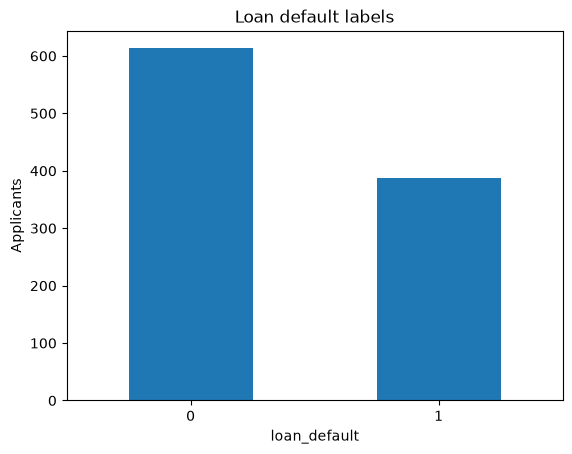

In [2]:
print(df["loan_default"].value_counts())
print((df["loan_default"].value_counts(normalize=True)*100).round(1))
df["loan_default"].value_counts().sort_index().plot.bar(rot=0, title="Loan default labels")
plt.ylabel("Applicants")
plt.show()

## 3. One-hot encode and keep the same 80/20 split

Each text category becomes a 0/1 indicator. `loan_default` stays separate as the target. The 200 test records are held out from training and GridSearchCV.

In [3]:
X = pd.get_dummies(df.drop(columns="loan_default"), dtype=int)
y = df["loan_default"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Encoded features:", X.shape[1])
print("Training rows:", len(X_train), "Test rows:", len(X_test))
display(X_train.head())

Encoded features: 32
Training rows: 800 Test rows: 200


,age,monthly_income_inr,years_employed,dependents,years_at_address,loan_amount_inr,loan_term_months,existing_loans,monthly_debt_payments_inr,credit_score,...,residence_type_Owned,residence_type_Rented,loan_purpose_Business,loan_purpose_Education,loan_purpose_Home improvement,loan_purpose_Medical,loan_purpose_Personal,loan_purpose_Vehicle,has_guarantor_No,has_guarantor_Yes
826,53,91000,5,2,18,1350000,48,1,23000,694,...,1,0,0,0,0,1,0,0,1,0
595,40,92000,6,2,17,1100000,48,0,20000,763,...,0,1,1,0,0,0,0,0,1,0
963,61,65000,13,4,8,1590000,60,1,27000,585,...,0,1,0,0,0,0,1,0,1,0
622,41,59000,1,1,18,1940000,36,0,21000,527,...,1,0,0,0,0,1,0,0,1,0
965,51,154000,8,2,7,70000,24,1,66000,491,...,1,0,0,0,0,0,1,0,0,1


## 4. Model 1: basic forest

In [ ]:
basic_model = RandomForestClassifier(random_state=42)
basic_model.fit(X_train, y_train)
print("Basic test accuracy:", round(basic_model.score(X_test, y_test), 3))
print("Basic test ROC AUC:", round(roc_auc_score(y_test, basic_model.predict_proba(X_test)[:, 1]), 3))

Basic test accuracy: 0.84
Basic test ROC AUC: 0.91


## 5. Model 2: manually set hyperparameters

`n_estimators=200` grows 200 trees instead of 100. `max_depth=9` limits how many questions each tree can ask along one path. The manual settings are fixed for this demonstration; a larger forest does not guarantee improvement on other data.

In [5]:
model = RandomForestClassifier(n_estimators=200, max_depth=9,
                               random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Number of trees:", len(model.estimators_))

Number of trees: 200


## Evaluate the current forest

The confusion matrix has actual outcomes in rows and predicted outcomes in columns. A false negative is a missed default; a false positive is a false alarm. Accuracy is the fraction of correct classes. ROC AUC evaluates how default probabilities rank the two classes across thresholds.

Training accuracy: 0.985
Test accuracy: 0.845
Test ROC AUC: 0.912
              precision    recall  f1-score   support

  No default       0.84      0.92      0.88       123
     Default       0.85      0.73      0.78        77

    accuracy                           0.84       200
   macro avg       0.85      0.82      0.83       200
weighted avg       0.85      0.84      0.84       200



,Predicted no default,Predicted default
Actual no default,113,10
Actual default,21,56


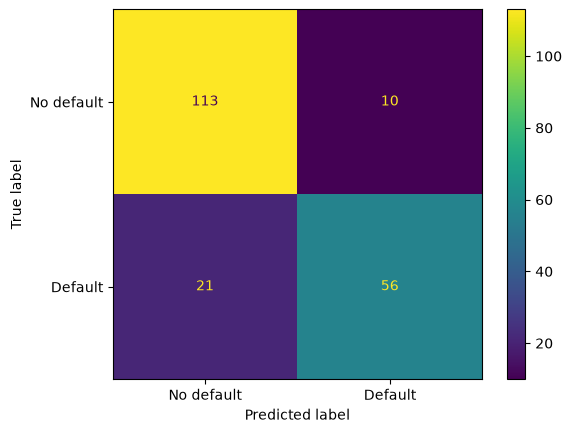

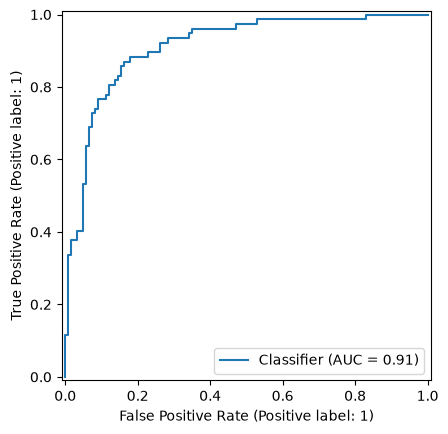

In [6]:
pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:, 1]
print("Training accuracy:", round(model.score(X_train, y_train), 3))
print("Test accuracy:", round(accuracy_score(y_test, pred), 3))
print("Test ROC AUC:", round(roc_auc_score(y_test, prob), 3))
print(classification_report(y_test, pred, target_names=["No default", "Default"], zero_division=0))
display(pd.DataFrame(confusion_matrix(y_test, pred, labels=[0,1]),
    index=["Actual no default", "Actual default"],
    columns=["Predicted no default", "Predicted default"]))
ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=[0,1], display_labels=["No default", "Default"])
plt.show()
RocCurveDisplay.from_predictions(y_test, prob)
plt.show()

### Read the result

Compare training and test accuracy for possible overfitting. The test set has 200 applicants, so one changed prediction shifts accuracy by 0.5 percentage points. ROC AUC uses probabilities, which need not move in exactly the same way as accuracy.

## Which inputs did the forest use?

This chart shows impurity-based importance. Correlated inputs can share importance; these bars do not establish causes of default.

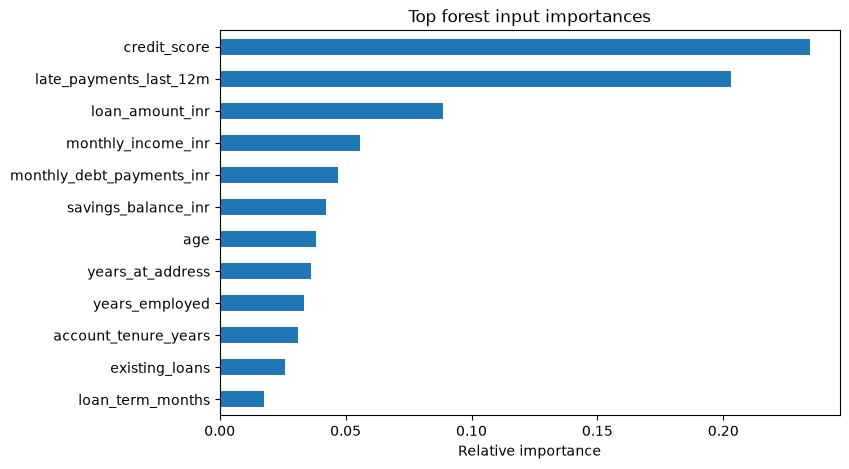

In [7]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.nlargest(12).sort_values().plot.barh(figsize=(8, 5))
plt.title("Top forest input importances")
plt.xlabel("Relative importance")
plt.show()

## Compare both models

In [8]:
rows = []
for name, fitted in [("Basic", basic_model), ("Manual hyperparameters", model)]:
    rows.append({"Model": name, "Train accuracy": fitted.score(X_train, y_train),
                 "Test accuracy": fitted.score(X_test, y_test),
                 "Test ROC AUC": roc_auc_score(y_test, fitted.predict_proba(X_test)[:, 1])})
display(pd.DataFrame(rows).round(3))

,Model,Train accuracy,Test accuracy,Test ROC AUC
0,Basic,1.000,0.840,0.910
1,Manual hyperparameters,0.985,0.845,0.912
